# From Earth to Plate - 04: Food waste by sector and the levers that move it

Maurice Baz & Dominika Bondyra - "From Earth to Plate", JH Data Patterns and Representations final project.

This notebook covers two deck slides:

- **Slide 7** - where US food surplus happens (tons) versus where its carbon lives (MMt CO2e), by supply-chain sector, plus the carbon intensity per ton of surplus.
- **Slide 10** - individual versus systemic levers: what one person saves by changing diet or waste, next to what an SB 1383-style rescue policy saves per US resident.

It cleanly replaces the earlier rough EDA (`refed_food_surplus_eda.ipynb`), which had two breaking bugs (a `read_excel` call on a nonexistent `.xlsx`, and references to an undefined `df`). Here: one `pd.read_csv` on the actual CSV, one consistent dataframe name (`refed`), and deck-styled figures saved to `figures/`.

## Data

- `data/ReFED_surplus_table(Surplus Data).csv` - US food surplus by sector, **ReFED 2025 estimates**. Five sectors (Residential, Farm, Manufacturing, Foodservice, Retail) with surplus tonnage (million tons), share of total surplus, embedded GHG (million metric tons CO2e), and dollar value ($B). The GHG header arrives mojibaked ("CO?e") and is renamed to `GHG (MMt CO2e)` on load.
- `data/Food_Product_Emissions.csv` - global mean GHG emissions per kg of food for 43 products, from Poore & Nemecek (2018), used here only for the slide-10 diet lever.

**Emissions basis decision (project-wide).** All per-kg numbers use the **"Total from Land to Retail"** column: Beef (beef herd) = 59.57 kg CO2e/kg versus Peas = 0.896 - the roughly 60:1 contrast quoted across the deck. The choice matters doubly in this notebook: the alternative "Total Global Average" column (beef 99.5, roughly 100:1) already folds **post-retail losses** into each food's footprint, so pairing it with waste tonnage would double-count waste. Land-to-retail keeps the per-kg basis and the waste analysis additive.

In [1]:
# Setup: imports, robust paths, house chart style (shared across all four notebooks)
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd()/'data').exists() else Path.cwd().parent
DATA, FIGS = ROOT/'data', ROOT/'figures'
FIGS.mkdir(exist_ok=True)

# House palette
SURFACE  = '#fcfcfb'   # figure + axes background
INK      = '#0b0b0b'   # primary ink (titles, callouts)
SUB      = '#52514e'   # secondary ink (subtitles, value labels)
MUT      = '#898781'   # muted (ticks, captions)
BASELINE = '#c3c2b7'   # axis baseline
GRID     = '#e1e0d9'   # hairline grid
BLUE     = '#2a78d6'   # slot 1 / sequential default hue
GREEN    = '#008300'   # slot 2
LIGHTBLUE = '#9ec5f4'  # de-emphasis step in the blue family

mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'DejaVu Sans'],
    'axes.edgecolor': BASELINE, 'axes.linewidth': 0.8,
    'xtick.color': MUT, 'ytick.color': MUT, 'axes.labelcolor': MUT,
    'text.color': INK,
    'grid.color': GRID, 'grid.linewidth': 0.8, 'grid.linestyle': '-',
    'axes.grid': False, 'figure.dpi': 110,
})

def style_barh_ax(ax):
    """House style for a horizontal-bar axes: hairline grid on the value axis
    only, drawn behind the data; no chart border box; baseline at x = 0."""
    ax.set_axisbelow(True)
    ax.grid(axis='x')
    for side in ('top', 'right', 'bottom'):
        ax.spines[side].set_visible(False)
    ax.spines['left'].set_color(BASELINE)
    ax.tick_params(length=0, labelsize=9.5)

def fmt1(v):
    """One decimal where it aids reading; drop it for effectively-integer values."""
    return f'{v:,.0f}' if abs(v - round(v)) < 0.05 else f'{v:,.1f}'

def save_fig(fig, name):
    out = FIGS/name
    fig.savefig(out, dpi=200, bbox_inches='tight', facecolor=SURFACE)
    print('saved', out)

In [2]:
# Load the ReFED sector table; repair the mojibaked GHG header on load
def read_refed(path):
    try:
        return pd.read_csv(path, encoding='utf-8')
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='cp1252')

refed = read_refed(DATA/'ReFED_surplus_table(Surplus Data).csv')
refed = refed.rename(columns={c: 'GHG (MMt CO2e)' for c in refed.columns if 'GHG' in c})
refed['pct_of_total'] = refed['% of total'].str.rstrip('%').astype(float)
# MMt CO2e per M tons of surplus == t CO2e per ton of surplus (the M cancels)
refed['co2e_per_ton'] = refed['GHG (MMt CO2e)'] / refed['Surplus (M tons)']

assert refed.shape[0] == 5, 'expected exactly 5 sectors'
assert refed[['Surplus (M tons)', 'GHG (MMt CO2e)']].isna().sum().sum() == 0

total_tons = refed['Surplus (M tons)'].sum()
total_ghg = refed['GHG (MMt CO2e)'].sum()
print(f'US totals (ReFED 2025 estimates): {total_tons:.1f} M tons of surplus, '
      f'{total_ghg:.1f} MMt CO2e embedded')
refed.sort_values('Surplus (M tons)', ascending=False)

US totals (ReFED 2025 estimates): 70.7 M tons of surplus, 220.9 MMt CO2e embedded


,Sector,Surplus (M tons),% of total,GHG (MMt CO2e),Value ($B),pct_of_total,co2e_per_ton
0,Residential,23.50,33.2%,100.00,141.0,33.2,4.255319
1,Farm,16.90,23.9%,3.56,13.4,23.9,0.210651
2,Manufacturing,13.20,18.6%,38.60,42.7,18.6,2.924242
3,Foodservice,12.50,17.7%,63.60,157.0,17.7,5.088000
4,Retail,4.63,6.5%,15.10,30.3,6.5,3.261339


## Slide 7 - tons wasted versus carbon embedded

ReFED sizes each sector's surplus two ways: tonnage and embedded GHG. We plot the two measures as side-by-side panels with the **same fixed row order** (sorted by surplus tons, descending) - that choice is the chart. If carbon tracked tonnage, the right panel would step down monotonically like the left; instead it scrambles, and the fixed rows make the flip visible at a glance.

Style choices: each panel shows exactly one measure, so each keeps a single hue (tons = blue, GHG = green) rather than a color per bar; the story row (Farm) is called out with an annotation, not a color change; with only 5 bars per panel, every bar gets a direct value label.

saved C:\Users\M\code\JH-2026-Final-Project\figures\fig_slide07_surplus_tons_vs_ghg.png


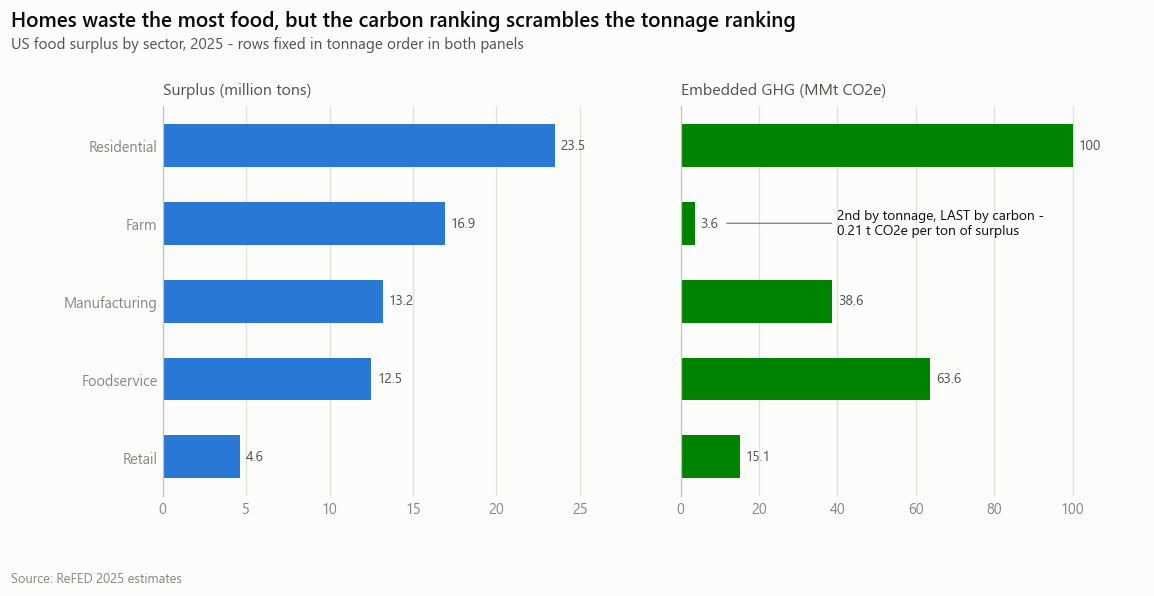

In [3]:
# Figure A (slide 7): two panels, same fixed row order (by surplus tons, desc)
order = refed.sort_values('Surplus (M tons)', ascending=False).reset_index(drop=True)
y = np.arange(len(order))
farm_i = int(order.index[order['Sector'] == 'Farm'][0])
farm_intensity = order.loc[farm_i, 'co2e_per_ton']

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6), sharey=True)
panels = [
    (axes[0], 'Surplus (M tons)', 'Surplus (million tons)', BLUE),
    (axes[1], 'GHG (MMt CO2e)', 'Embedded GHG (MMt CO2e)', GREEN),
]
for ax, col, header, hue in panels:
    vals = order[col].to_numpy()
    ax.barh(y, vals, height=0.55, color=hue)
    style_barh_ax(ax)
    ax.set_title(header, loc='left', fontsize=10.5, color=SUB, pad=8)
    ax.set_xlim(0, vals.max() * 1.18)
    for yi, v in zip(y, vals):
        ax.text(v + vals.max() * 0.015, yi, fmt1(v),
                va='center', ha='left', fontsize=9, color=SUB)
axes[0].set_yticks(y, order['Sector'])
axes[0].invert_yaxis()   # biggest surplus on top; sharey flips both panels

# The story annotation lives on the GHG panel: Farm flips from 2nd to last
axes[1].annotate(
    f'2nd by tonnage, LAST by carbon -\n{farm_intensity:.2f} t CO2e per ton of surplus',
    xy=(11, farm_i), xytext=(40, farm_i), va='center', ha='left',
    fontsize=9, color=INK,
    arrowprops=dict(arrowstyle='-', color=MUT, lw=0.9))

fig.suptitle('Homes waste the most food, but the carbon ranking scrambles the tonnage ranking',
             x=0.005, y=1.07, ha='left', fontsize=13.5, fontweight=600, color=INK)
fig.text(0.005, 0.995, 'US food surplus by sector, 2025 - rows fixed in tonnage order in both panels',
         ha='left', fontsize=10, color=SUB)
fig.text(0.005, -0.06, 'Source: ReFED 2025 estimates', ha='left', fontsize=8.5, color=MUT)
fig.subplots_adjust(wspace=0.12)
save_fig(fig, 'fig_slide07_surplus_tons_vs_ghg.png')
plt.show()

**Takeaway.** Residential is No. 1 on BOTH measures: 23.5 M tons of surplus (33.2% of the 70.7 M-ton US total) and 100 MMt CO2e of the 220.9 MMt total. Farm is 2nd by tonnage (16.9 M tons) but LAST by carbon (3.56 MMt); Foodservice is 4th by tonnage (12.5 M tons) but 2nd by carbon (63.6 MMt). Tonnage is not a map to the carbon - the per-ton rate below explains the flip.

### Carbon intensity - GHG per ton of surplus

Dividing each sector's embedded GHG by its tonnage gives a rate: MMt CO2e per M tons, which is simply **t CO2e per ton of surplus** (the millions cancel). The rate isolates *why* the rankings flip: food wasted downstream has already accumulated the whole supply chain - farming, processing, transport, packaging, retail - and is likelier to end up in a landfill, while on-farm losses have accumulated almost none of that. Farm, the low-rate outlier, is de-emphasized with the light blue step of the same hue family; all other bars share the standard sequential blue.

saved C:\Users\M\code\JH-2026-Final-Project\figures\fig_slide07_carbon_intensity.png


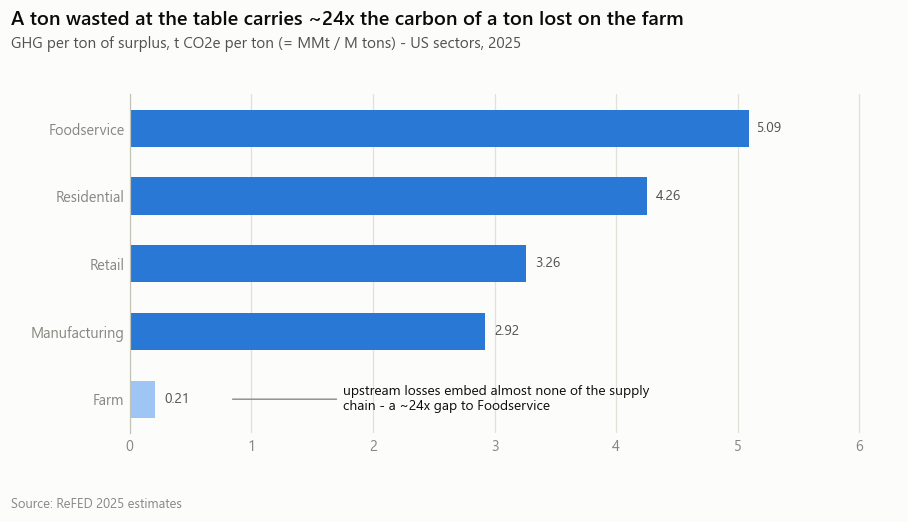

In [4]:
# Figure B (slide 7 support): carbon intensity of a wasted ton, ranked
inten = refed.sort_values('co2e_per_ton', ascending=False).reset_index(drop=True)
table_vs_farm = inten['co2e_per_ton'].iloc[0] / inten['co2e_per_ton'].iloc[-1]

fig, ax = plt.subplots(figsize=(9, 4))
yi_pos = np.arange(len(inten))
colors = [LIGHTBLUE if s == 'Farm' else BLUE for s in inten['Sector']]
ax.barh(yi_pos, inten['co2e_per_ton'], height=0.55, color=colors)
style_barh_ax(ax)
ax.set_yticks(yi_pos, inten['Sector'])
ax.invert_yaxis()
ax.set_xlim(0, inten['co2e_per_ton'].max() * 1.24)
for yy, v in zip(yi_pos, inten['co2e_per_ton']):
    ax.text(v + 0.07, yy, f'{v:.2f}', va='center', ha='left', fontsize=9, color=SUB)

ax.annotate(
    f'upstream losses embed almost none of the supply\nchain - a ~{table_vs_farm:.0f}x gap to Foodservice',
    xy=(0.82, 4), xytext=(1.75, 4), va='center', ha='left', fontsize=9, color=INK,
    arrowprops=dict(arrowstyle='-', color=MUT, lw=0.9))

fig.suptitle(f'A ton wasted at the table carries ~{table_vs_farm:.0f}x the carbon of a ton lost on the farm',
             x=0.005, y=1.07, ha='left', fontsize=13, fontweight=600, color=INK)
fig.text(0.005, 0.985, 'GHG per ton of surplus, t CO2e per ton (= MMt / M tons) - US sectors, 2025',
         ha='left', fontsize=10, color=SUB)
fig.text(0.005, -0.06, 'Source: ReFED 2025 estimates', ha='left', fontsize=8.5, color=MUT)
save_fig(fig, 'fig_slide07_carbon_intensity.png')
plt.show()

**Takeaway.** Foodservice tops the rate at 5.09 t CO2e per ton of surplus, then Residential 4.26, Retail 3.26, Manufacturing 2.92 - and Farm at just 0.21. A ton wasted at the table carries roughly **24x** the carbon of a ton lost on the farm, because downstream waste embeds the full supply chain. The high-intensity downstream tiers - retail and foodservice - are exactly the ones California's SB 1383 targets with its edible-food donation mandate, which motivates the slide-10 policy lever below.

## Slide 10 - individual versus systemic levers

We put three levers on ONE per-person scale (t CO2e avoided per US resident per year) so the magnitudes are honestly comparable - no log tricks, no dual axes:

1. **Personal diet** - replace all US per-capita beef consumption (26.35 kg/yr) with chicken. Savings per kg = beef land-to-retail minus poultry land-to-retail (project basis column, see Data section).
2. **Personal waste** - zero out your per-capita share of residential food-waste GHG: 100 MMt spread over 340.1 M residents.
3. **Policy (SB 1383-style what-if)** - businesses rescue 20% of business-sector surplus GHG (Manufacturing + Foodservice + Retail). SB 1383's edible-food provision targets recovering 20% of edible food that would otherwise be disposed - we borrow that 20% as the scenario dial. Per resident this looks tiny, but it requires NO individual behavior change.

External figures (source-verified): USDA Economic Research Service, per-capita beef consumption (retail weight): 58.1 lb (26.35 kg) per person, 2023 (2024 estimated unchanged); U.S. Census Bureau, Vintage 2024 Population Estimates: 340.1 million (July 1, 2024); Jones et al. (2025), National contributions to climate change, Scientific Data - via Our World in Data, per-capita GHG emissions including land use (CO2+CH4+N2O, IPCC AR6 GWP100): United States 2024 = 17.53 t.

In [5]:
# Slide 10 levers - computed exactly from the data + cited external figures
per_kg = pd.read_csv(DATA/'Food_Product_Emissions.csv')
BASIS = 'Total from Land to Retail'   # project-wide emissions basis
beef = per_kg.loc[per_kg['Food product'] == 'Beef (beef herd)', BASIS].iloc[0]
chicken = per_kg.loc[per_kg['Food product'] == 'Poultry Meat', BASIS].iloc[0]

# External figures - source-verified (full citations in the Sources cell)
US_POP = 340.1e6        # U.S. Census Bureau, Vintage 2024 Population Estimates (July 1, 2024)
BEEF_KG_YR = 26.35      # USDA ERS per-capita beef, retail weight: 58.1 lb, 2023 (2024 est. unchanged)
US_FOOTPRINT_T = 17.53  # Jones et al. (2025) via Our World in Data: US 2024, GHG incl. land use

# Lever 1 - personal diet: beef -> chicken, t CO2e per person-year
lever_diet = BEEF_KG_YR * (beef - chicken) / 1000

# Lever 2 - personal waste: your share of residential food-waste GHG
resid_ghg = refed.loc[refed['Sector'] == 'Residential', 'GHG (MMt CO2e)'].iloc[0]
lever_waste = resid_ghg * 1e6 / US_POP   # MMt -> t, spread over the population

# Lever 3 - policy: rescue 20% of BUSINESS-sector surplus GHG
biz = refed[refed['Sector'].isin(['Manufacturing', 'Foodservice', 'Retail'])]
biz_ghg = biz['GHG (MMt CO2e)'].sum()
policy_total_mmt = 0.20 * biz_ghg
lever_policy = policy_total_mmt * 1e6 / US_POP
people_equiv = policy_total_mmt * 1e6 / lever_diet   # diet-swaps the policy equals

print(f'Beef (beef herd) land-to-retail: {beef:.2f} kg CO2e/kg | Poultry Meat: '
      f'{chicken:.2f} | delta {beef - chicken:.2f}')
print(f'Lever 1  personal diet   beef -> chicken at {BEEF_KG_YR} kg/yr: '
      f'{lever_diet:.2f} t CO2e per person-year')
print(f'Lever 2  personal waste  residential {resid_ghg:.0f} MMt / '
      f'{US_POP/1e6:.1f} M people: {lever_waste:.2f} t per person-year')
print(f'Lever 3  policy          20% of business-sector {biz_ghg:.1f} MMt = '
      f'{policy_total_mmt:.1f} MMt/yr -> {lever_policy:.2f} t per US resident')
print(f'         ...that policy total equals the beef -> chicken swaps of '
      f'~{people_equiv/1e6:.1f} MILLION people')
print(f'Context: the diet lever is ~{100*lever_diet/US_FOOTPRINT_T:.0f}% of the '
      f'{US_FOOTPRINT_T} t US per-capita footprint (Jones et al. 2025 via OWID, 2024)')

Beef (beef herd) land-to-retail: 59.57 kg CO2e/kg | Poultry Meat: 6.09 | delta 53.48


Lever 1  personal diet   beef -> chicken at 26.35 kg/yr: 1.41 t CO2e per person-year
Lever 2  personal waste  residential 100 MMt / 340.1 M people: 0.29 t per person-year
Lever 3  policy          20% of business-sector 117.3 MMt = 23.5 MMt/yr -> 0.07 t per US resident
         ...that policy total equals the beef -> chicken swaps of ~16.6 MILLION people
Context: the diet lever is ~8% of the 17.53 t US per-capita footprint (Jones et al. 2025 via OWID, 2024)


saved C:\Users\M\code\JH-2026-Final-Project\figures\fig_slide10_levers.png


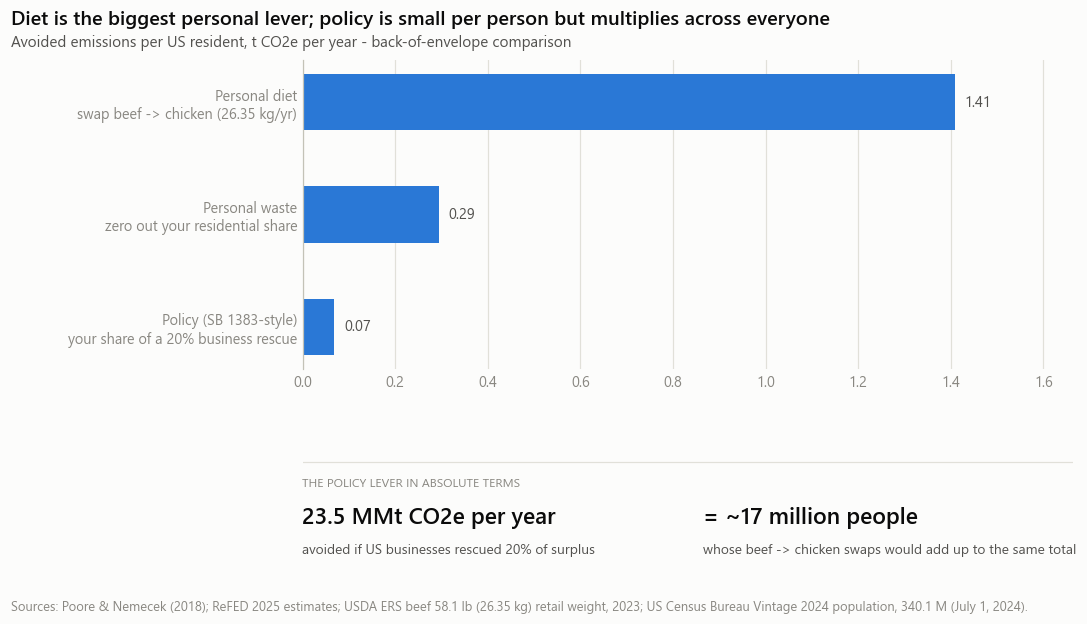

In [6]:
# Figure C (slide 10): per-person lever comparison + stat tiles for the absolutes
levers = pd.DataFrame({
    'label': [f'Personal diet\nswap beef -> chicken ({BEEF_KG_YR} kg/yr)',
              'Personal waste\nzero out your residential share',
              'Policy (SB 1383-style)\nyour share of a 20% business rescue'],
    'value': [lever_diet, lever_waste, lever_policy],
})

fig = plt.figure(figsize=(10, 5.0))
# wide left margin keeps the two-line lever labels INSIDE the figure, so the
# figure-left title/caption and the axes stay on one visual left edge
gs = fig.add_gridspec(2, 1, height_ratios=[3.1, 1.0], hspace=0.45,
                      left=0.27, right=0.97, top=0.96, bottom=0.05)
ax = fig.add_subplot(gs[0])
tiles = fig.add_subplot(gs[1])
tiles.axis('off')

yl = np.arange(len(levers))
ax.barh(yl, levers['value'], height=0.5, color=BLUE)
style_barh_ax(ax)
ax.set_yticks(yl, levers['label'])
ax.invert_yaxis()
ax.set_xlim(0, lever_diet * 1.18)
for yy, v in zip(yl, levers['value']):
    ax.text(v + lever_diet * 0.015, yy, f'{v:.2f}',
            va='center', ha='left', fontsize=9.5, color=SUB)

# Stat tiles: the policy lever in absolute terms
tiles.set_xlim(0, 1); tiles.set_ylim(0, 1.3)
tiles.axhline(1.28, color=GRID, lw=0.8)
tiles.text(0, 1.0, 'THE POLICY LEVER IN ABSOLUTE TERMS', fontsize=8, color=MUT, va='center')
tiles.text(0, 0.56, f'{policy_total_mmt:.1f} MMt CO2e per year',
           fontsize=15, fontweight=600, color=INK, va='center')
tiles.text(0, 0.14, 'avoided if US businesses rescued 20% of surplus',
           fontsize=9, color=SUB, va='center')
tiles.text(0.52, 0.56, f'= ~{people_equiv/1e6:.0f} million people',
           fontsize=15, fontweight=600, color=INK, va='center')
tiles.text(0.52, 0.14, "whose beef -> chicken swaps would add up to the same total",
           fontsize=9, color=SUB, va='center')

fig.suptitle('Diet is the biggest personal lever; policy is small per person but multiplies across everyone',
             x=0.005, y=1.05, ha='left', fontsize=13, fontweight=600, color=INK)
fig.text(0.005, 0.985, 'Avoided emissions per US resident, t CO2e per year - back-of-envelope comparison',
         ha='left', fontsize=10, color=SUB)
fig.text(0.005, -0.04,
         'Sources: Poore & Nemecek (2018); ReFED 2025 estimates; USDA ERS beef 58.1 lb (26.35 kg) '
         'retail weight, 2023; US Census Bureau Vintage 2024 population, 340.1 M (July 1, 2024).',
         ha='left', fontsize=8.5, color=MUT)
save_fig(fig, 'fig_slide10_levers.png')
plt.show()

**Takeaway (the slide-10 thesis).** Diet is the biggest PERSONAL lever: swapping US per-capita beef for chicken avoids **~1.41 t CO2e per year** - roughly 8% of the 17.53 t US per-capita footprint (Jones et al. 2025 via Our World in Data, 2024) and about 4.8x the **~0.29 t** from zeroing out your share of residential food-waste emissions. The policy lever is the smallest per person (**~0.07 t**) - but it demands no individual behavior change, and its **23.5 MMt/yr** total equals the beef -> chicken swaps of **~17 MILLION people**. Personal choices move one person at a time; policy moves everyone at once. Both matter - that is the slide.

## Caveats (required reading before quoting slide 10)

- **ReFED figures are US-only, 2025 model estimates** - modeled surplus and embedded-GHG values, not measurements; we take the sector table as given without re-deriving it.
- **Per-kg emissions are global means** (Poore & Nemecek 2018, ~2010-era data); US beef production is not the global average system, so the diet lever is indicative, not US-specific.
- **SB 1383 is a California law** (covering ~39 M of 340.1 M US residents, about 11%); applying a 20% business-sector rescue nationwide is a what-if scenario, not existing policy. We also apply the 20% to embedded GHG, a simplification of the law's edible-food-recovery target.
- **Back-of-envelope, not a policy analysis**: mass-for-mass beef -> chicken substitution (no protein equivalence), no rebound effects, no landfill-methane timing, no cost side.
- **Retail weight vs. actual intake**: the 26.35 kg/yr beef figure is retail weight, which includes some bone and trim, so it slightly overstates bone-free intake relative to Poore & Nemecek's per-kg functional unit - we use the standard retail-weight figure knowingly.

## Limitations

- **Surplus is not exactly waste**: ReFED's "surplus" includes food that is donated, recycled, or otherwise not eaten by people as intended; treating all of it as avoidable overstates the achievable savings.
- **Embedded-GHG accounting**: ReFED's sector GHG blends upstream (production) and downstream (disposal) emissions under its own model assumptions; the carbon-intensity ratio (t CO2e per ton) inherits those assumptions.
- **Static comparison**: levers are annual steady-state numbers; real adoption curves, substitution diets, and supply responses would change the totals.
- **Two datasets, two scopes**: ReFED is US 2025; Poore & Nemecek is global ~2010. Combining them (the diet lever next to the waste levers) is a deliberate, clearly-labeled approximation for slide 10's framing, not a unified model.

## Sources

- **ReFED (2025)** - US food surplus by sector, 2025 estimates. Sector briefs:
  - Farm: https://refed.org/downloads/by-sector-farm-2025.pdf
  - Manufacturing: https://refed.org/downloads/by-sector-manufacturing-2025.pdf
  - Retail: https://refed.org/downloads/by-sector-retail-2025.pdf
  - Foodservice: https://refed.org/downloads/by-sector-foodservice-2025.pdf
  - Residential: https://refed.org/downloads/by-sector-residential-2025.pdf
  - ReFED Insights Engine: https://insights.refed.org
- **Poore, J. & Nemecek, T. (2018)** - "Reducing food's environmental impacts through producers and consumers", *Science* 360(6392); per-kg emissions as distributed via Our World in Data.
- **USDA Economic Research Service** - per-capita beef consumption (retail weight): 58.1 lb (26.35 kg) per person, 2023; 2024 estimated unchanged.
- **U.S. Census Bureau** - Vintage 2024 Population Estimates: 340.1 million (July 1, 2024); California ~39 M.
- **Jones et al. (2025)** - "National contributions to climate change", *Scientific Data* - via Our World in Data; per-capita GHG emissions including land use (CO2+CH4+N2O, IPCC AR6 GWP100): United States 2024 = 17.53 t, World 2024 = 6.67 t CO2e/person/yr.
- **California SB 1383 (2016)** - Short-Lived Climate Pollutants Reduction Act; includes the mandate to recover 20% of edible food that would otherwise be disposed of by 2025 (retail/foodservice tiers).